In [57]:
# Data Manipulation
import pandas as pd
import numpy as np

# Text Processing
import re
import string

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Model Saving
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [58]:
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')


In [59]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [60]:
df.tail()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
9822,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9823,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9824,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9825,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...
9826,1984-09-23,Threads,Documentary style account of a nuclear holocau...,13.354,186,7.8,en,"War, Drama, Science Fiction",https://image.tmdb.org/t/p/original/lBhU4U9Eeh...


In [61]:
df.shape

(9827, 9)

In [62]:
df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='object')

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [64]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [65]:
df.isnull().sum()

,0
Release_Date,0
Title,0
Overview,0
Popularity,0
Vote_Count,0
Vote_Average,0
Original_Language,0
Genre,0
Poster_Url,0


In [66]:
df.duplicated().sum()

np.int64(0)

In [67]:
df['Genre'].unique()

array(['Action, Adventure, Science Fiction', 'Crime, Mystery, Thriller',
       'Thriller', ..., 'Comedy, TV Movie, Romance',
       'Science Fiction, Fantasy, Family, Music',
       'War, Drama, Science Fiction'], dtype=object)

In [68]:
df['Original_Language'].value_counts().head(10)

,count
Original_Language,
en,7570
ja,645
es,339
fr,292
ko,170
zh,129
it,123
cn,109
ru,83


In [69]:
df.drop_duplicates(inplace=True)

In [70]:
df.dropna(inplace=True)

In [71]:
df.reset_index(drop=True, inplace=True)

In [72]:
df.shape

(9827, 9)

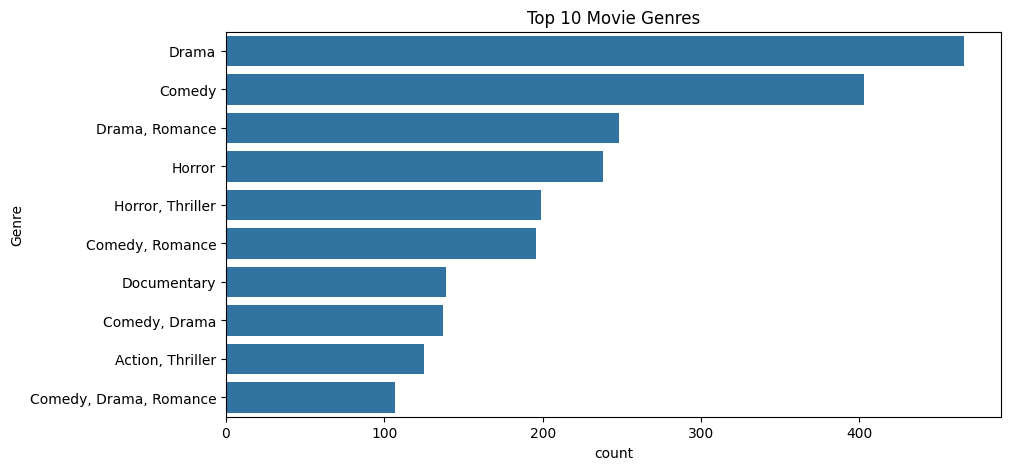

In [73]:
#Top 10 genres
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y='Genre',
    order=df['Genre'].value_counts().head(10).index
)

plt.title("Top 10 Movie Genres")
plt.show()

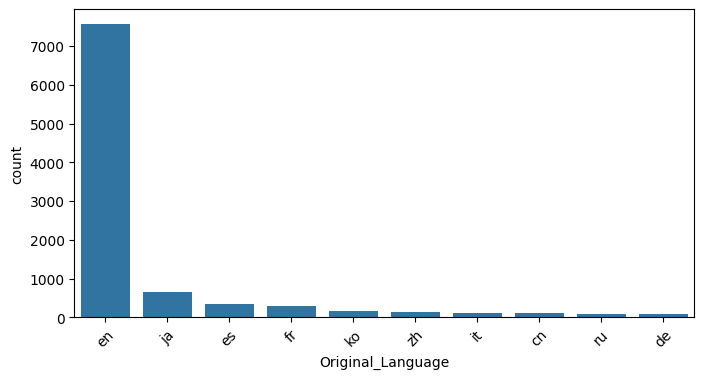

In [74]:
#Top languages
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x='Original_Language',
    order=df['Original_Language'].value_counts().head(10).index
)

plt.xticks(rotation=45)
plt.show()

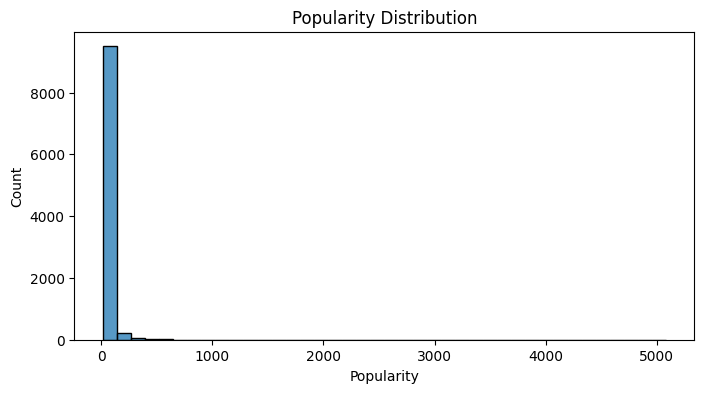

In [75]:
#Popularity distribution.

plt.figure(figsize=(8,4))

sns.histplot(df['Popularity'], bins=40)

plt.title("Popularity Distribution")

plt.show()

In [76]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])

In [77]:
df['Release_Year'] = df['Release_Date'].dt.year

In [78]:
df[['Title','Release_Year']].head()

,Title,Release_Year
0,Spider-Man: No Way Home,2021
1,The Batman,2022
2,No Exit,2022
3,Encanto,2021
4,The King's Man,2021


In [79]:
df['Genre'].head()

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"


In [80]:
df['Genre'] = df['Genre'].str.replace(',', ' ', regex=False)

In [97]:
df['Genre'] = df['Genre'].str.lower()

genre_map = {
    "Science Fiction": "science_fiction",
    "TV Movie": "tv_movie",
    "War & Politics": "war_politics"
}

for old, new in genre_map.items():
    df['Genre'] = df['Genre'].str.replace(old.lower(), new, regex=False)

df['Genre'] = df['Genre'].str.replace(",", "", regex=False)

In [123]:
df["tags"] = (
    df["Title"] + " " +
    (df["Genre"] + " ") * 10 +
    df["Overview"]
)

In [150]:
def clean_text(text):

    text = text.lower()

    # Remove punctuation
    text = re.sub(r'[^a-zA-Z_\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [151]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=12000,
    ngram_range=(1,3),
    sublinear_tf=True
)

df["tags"] = df["tags"].apply(clean_text)

tfidf_matrix = tfidf.fit_transform(df["tags"])

similarity = cosine_similarity(tfidf_matrix)

In [135]:
print(tfidf.get_feature_names_out()[:50])

['aaron' 'abandon' 'abandoned' 'abandoning' 'abandons' 'abbey' 'abby'
 'abduct' 'abducted' 'abduction' 'abducts' 'abigail' 'abilities' 'ability'
 'able' 'able save' 'aboard' 'abraham' 'abroad' 'abrupt' 'absence'
 'absent' 'absolute' 'absolutely' 'absurd' 'abuse' 'abused' 'abusive'
 'abyss' 'academia' 'academic' 'academy' 'accept' 'acceptance' 'accepted'
 'accepts' 'access' 'accident' 'accidental' 'accidentally' 'accidents'
 'acclaimed' 'accompanied' 'accompanies' 'accompany' 'accompanying'
 'accomplish' 'accomplished' 'according' 'account']


In [136]:
!pip install rapidfuzz

In [137]:
from rapidfuzz import process

In [138]:
movie_titles = df['Title'].tolist()

In [139]:
from rapidfuzz import process, fuzz

In [140]:
def recommend(movie_name, n=5):

    # ---------- Find closest movie ----------
    match = process.extractOne(
        movie_name,
        movie_titles,
        scorer=fuzz.WRatio,
        score_cutoff=85
    )

    if match is None:
        return "Movie not found."

    movie = match[0]

    idx = df[df["Title"] == movie].index[0]

    scores = list(enumerate(similarity[idx]))

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = []

    for i, score in scores[1:]:

        # Skip weak matches
        if score < 0.18:
            continue

        m = df.iloc[i]

        recommendations.append({
            "Movie": m["Title"],
            "Similarity": f"{score*100:.1f}%",
            "Genre": m["Genre"],
            "Rating": m["Vote_Average"],
            "Popularity": round(m["Popularity"], 2),
            "Release Year": m["Release_Year"],
            "Poster": m["Poster_Url"]
        })

        # Stop after n recommendations
        if len(recommendations) == n:
            break

    return movie, pd.DataFrame(recommendations)

In [141]:
recommend("Avatar 2")

('Avatar 2',
                            Movie Similarity  \
 0                     Inuyashiki      81.6%   
 1              X-Men: Apocalypse      81.4%   
 2                        Hellboy      79.0%   
 3  Transformers: The Last Knight      78.0%   
 4  Marvel One-Shot: Agent Carter      77.5%   
 
                                          Genre  Rating  Popularity  \
 0  action  adventure  science_fiction  fantasy     7.7       37.80   
 1  action  adventure  science_fiction  fantasy     6.5       98.47   
 2  fantasy  action  adventure  science_fiction     5.5       91.66   
 3  action  adventure  science_fiction  fantasy     6.0       89.87   
 4  action  adventure  science_fiction  fantasy     7.4       25.69   
 
    Release Year                                             Poster  
 0          2018  https://image.tmdb.org/t/p/original/lyqkQ6y7d4...  
 1          2016  https://image.tmdb.org/t/p/original/2mtQwJKVKQ...  
 2          2019  https://image.tmdb.org/t/p/original/bk8Ly

In [142]:
idx1 = df[df["Title"]=="Avatar"].index[0]
idx2 = df[df["Title"]=="Avatar 2"].index[0]

print(similarity[idx1][idx2])

0.15787900076912606


In [143]:
feature_names = tfidf.get_feature_names_out()

row = tfidf_matrix[df[df["Title"]=="Avatar"].index[0]]

top = row.toarray().flatten().argsort()[-20:]

for i in reversed(top):
    print(feature_names[i])

adventure fantasy science_fiction
fantasy science_fiction action
fantasy science_fiction
action adventure fantasy
science_fiction action adventure
adventure fantasy
science_fiction action
action adventure
science_fiction
fantasy
adventure
nd century
avatar
pandora
action
nd
dispatched
orders
protecting
civilization


In [144]:
movie = "Avatar"

idx = df[df["Title"] == movie].index[0]

scores = sorted(
    list(enumerate(similarity[idx])),
    key=lambda x: x[1],
    reverse=True
)

for i in range(15):
    print(
        df.iloc[scores[i][0]]["Title"],
        "->",
        round(scores[i][1], 3)
    )

Avatar -> 1.0
Krull -> 0.823
Doctor Strange -> 0.813
Thor: Ragnarok -> 0.802
Mythica: A Quest for Heroes -> 0.799
X-Men: Days of Future Past -> 0.793
Man of Steel -> 0.78
Marvel One-Shot: The Consultant -> 0.769
Justice League -> 0.768
Zack Snyder's Justice League -> 0.764
The Scorpion King 2: Rise of a Warrior -> 0.746
Fantastic Four -> 0.727
Small Soldiers -> 0.498
Dragonball Evolution -> 0.474
Final Fantasy VII: Advent Children -> 0.455


In [145]:
movie = "Avatar"

idx = df[df["Title"] == movie].index[0]

scores = sorted(
    list(enumerate(similarity[idx])),
    key=lambda x: x[1],
    reverse=True
)

for i in range(10):
    print(df.iloc[scores[i][0]]["Title"], "->", round(scores[i][1], 3))

Avatar -> 1.0
Krull -> 0.823
Doctor Strange -> 0.813
Thor: Ragnarok -> 0.802
Mythica: A Quest for Heroes -> 0.799
X-Men: Days of Future Past -> 0.793
Man of Steel -> 0.78
Marvel One-Shot: The Consultant -> 0.769
Justice League -> 0.768
Zack Snyder's Justice League -> 0.764


In [146]:
df[df["Title"].str.contains("Avatar", case=False)][
    ["Title", "Genre", "Release_Year"]
]

,Title,Genre,Release_Year
92,Avatar,action adventure fantasy science_fiction,2009
867,The King's Avatar: For the Glory,animation action adventure fantasy,2019
1061,Avatar 2,action adventure science_fiction fantasy,2022
2930,Avatar: Creating the World of Pandora,documentary,2010
3524,Avatar: Scene Deconstruction,documentary,2009
8370,Avatar Spirits,documentary,2010


In [147]:
df[df["Title"]=="Avatar"]["tags"].values[0]

'avatar action adventure fantasy science_fiction action adventure fantasy science_fiction action adventure fantasy science_fiction action adventure fantasy science_fiction action adventure fantasy science_fiction action adventure fantasy science_fiction action adventure fantasy science_fiction action adventure fantasy science_fiction action adventure fantasy science_fiction action adventure fantasy science_fiction in the nd century a paraplegic marine is dispatched to the moon pandora on a unique mission but becomes torn between following orders and protecting an alien civilization'

In [148]:
df[df["Title"]=="Avatar"]["Overview"].values[0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

In [149]:
df[df["Genre"].str.contains("Science Fiction", case=False)][
    ["Title", "Genre"]
].head(20)

,Title,Genre


In [121]:
print(tfidf.get_feature_names_out()[:50])

NotFittedError: Vocabulary not fitted or provided

In [89]:
recommend("AVATAR")

('ARQ',
                        Movie  Similarity                              Genre  \
 0                 Boss Level       0.309  Action  Science Fiction  Thriller   
 1                I Am Mortal       0.273    Science Fiction  Fantasy  Drama   
 2                   Automata       0.241          Thriller  Science Fiction   
 3  Resident Evil: Apocalypse       0.216    Horror  Action  Science Fiction   
 4        My Boyfriend's Meds       0.200                             Comedy   
 
    Rating  Popularity  Release Year  \
 0     6.9       42.84          2021   
 1     5.3       29.33          2021   
 2     5.8       23.22          2014   
 3     6.4       27.79          2004   
 4     7.1       21.87          2020   
 
                                               Poster  
 0  https://image.tmdb.org/t/p/original/i6QFXv4lZy...  
 1  https://image.tmdb.org/t/p/original/3ZNbjTwJ36...  
 2  https://image.tmdb.org/t/p/original/h7SEtIWOfL...  
 3  https://image.tmdb.org/t/p/original/yzNQ

In [90]:
recommend("avatr")

('Avatar',
                    Movie  Similarity  \
 0  Hellraiser: Bloodline       0.223   
 1              Apollo 18       0.218   
 2            Meteor Moon       0.211   
 3             The Matrix       0.206   
 4   Stand by Me Doraemon       0.204   
 
                                          Genre  Rating  Popularity  \
 0                      Horror  Science Fiction     5.3       14.13   
 1            Horror  Thriller  Science Fiction     5.3       18.64   
 2                   Adventure  Science Fiction     2.6       14.16   
 3                      Action  Science Fiction     8.2       98.07   
 4  Animation  Family  Science Fiction  Fantasy     7.3       82.91   
 
    Release Year                                             Poster  
 0          1996  https://image.tmdb.org/t/p/original/eXeQKyfWzc...  
 1          2011  https://image.tmdb.org/t/p/original/oW6oUKY2oi...  
 2          2020  https://image.tmdb.org/t/p/original/kagwvZq6nT...  
 3          1999  https://image.t